In [ ]:
!pip install --upgrade sympy
!pip install --upgrade torch torchvision torchaudio

ERROR: Operation cancelled by user


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import h5py
import os
import glob
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, accuracy_score, roc_auc_score,
                             recall_score, f1_score, roc_curve,
                             precision_recall_curve, average_precision_score)
from sklearn.metrics import precision_score

# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)


Using device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# UPDATE

In [ ]:

# --- Model Architecture ---
class MIL_Max_Pooling_Model(nn.Module):
    def __init__(self, feature_size=1024):
        super(MIL_Max_Pooling_Model, self).__init__()
        self.feature_extractor = nn.Sequential(nn.Linear(feature_size, 512),
                                               nn.ReLU(),
                                               nn.Dropout(0.25)
                                               )

        self.classifier = nn.Sequential(nn.Linear(512, 1)
                                        #nn.Sigmoid()
                                        )

    def forward(self, x):
        x = x.squeeze(0)
        h = self.feature_extractor(x)
        m, _ = torch.max(h, dim=0, keepdim=True)
        return self.classifier(m)

# --- Dataset Loader ---
class MIL_Dataset(Dataset):
    def __init__(self, root_dir):
        self.file_paths, self.labels = [], []
        for label_str, label_val in [("TUMOR", 1), ("NORMAL", 0)]:
            folder_path = os.path.join(root_dir, label_str)
            files = glob.glob(os.path.join(folder_path, "*.h5"))
            self.file_paths.extend(files)
            self.labels.extend([label_val] * len(files))
    def __len__(self): return len(self.file_paths)
    def __getitem__(self, idx):
        with h5py.File(self.file_paths[idx], 'r') as f:
            features = np.array(f['features']).astype('float32')
        return torch.from_numpy(features), torch.tensor([self.labels[idx]], dtype=torch.float32)



# --- Training Function (Early Stopping: Loss | Best Model: AUC) ---
def train_model(model, extractor_name, base_path, run_id):
    torch.cuda.empty_cache()

    print(f"\nTraining: {extractor_name} | Run {run_id}")

    train_loader = DataLoader(MIL_Dataset(os.path.join(base_path, 'train')), batch_size=1, shuffle=True)
    val_loader = DataLoader(MIL_Dataset(os.path.join(base_path, 'val')), batch_size=1, shuffle=False)

    optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)
    criterion = nn.BCEWithLogitsLoss()


    best_val_loss = float('inf')
    best_val_auc = 0.0

    patience = 15
    counter = 0

    save_path = f"/content/drive/MyDrive/Max_pooling_MIL_Models/best_model_{extractor_name}_run{run_id}.pth"

    for epoch in range(30):
        model.train()
        for features, label in train_loader:
            features, label = features.to(device), label.to(device)
            optimizer.zero_grad()
            loss = criterion(model(features), label)
            loss.backward()
            optimizer.step()

        model.eval()
        val_loss, y_true_val, y_probs_val = 0, [], []
        with torch.no_grad():
            for features, label in val_loader:
                logits = model(features.to(device))
                val_loss += criterion(logits, label.to(device)).item()

                prob = torch.sigmoid(logits).item()
                y_probs_val.append(prob)
                y_true_val.append(int(label.item()))

        avg_val_loss = val_loss / len(val_loader)
        current_val_auc = roc_auc_score(y_true_val, y_probs_val) if len(set(y_true_val)) > 1 else 0.0

        print(f"Epoch {epoch+1:02d}/30 | Val Loss: {avg_val_loss:.4f} | Val AUC: {current_val_auc:.4f}")

        if current_val_auc > best_val_auc:
            best_val_auc = current_val_auc
            torch.save(model.state_dict(), save_path)
            print(f"--> \n[SAVE] Best model updated with High AUC: {best_val_auc:.4f}\n")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            counter = 0
        else:
            counter += 1
            print(f"No Loss improvement. Patience: {counter}/{patience}")
            if counter >= patience:
                print(f"Early stopping triggered based on Val Loss at epoch {epoch+1}")
                break

    return save_path

# **KimiaNet**


Starting Averaged Evaluation for KimiaNet (Train -> Test x 5)...

RUN 1/5 for KimiaNet

Training: KimiaNet | Run 0
Epoch 01/30 | Val Loss: 0.2780 | Val AUC: 0.9520
--> 
[SAVE] Best model updated with High AUC: 0.9520

Epoch 02/30 | Val Loss: 0.3493 | Val AUC: 0.9535
--> 
[SAVE] Best model updated with High AUC: 0.9535

No Loss improvement. Patience: 1/15
Epoch 03/30 | Val Loss: 0.3238 | Val AUC: 0.9520
No Loss improvement. Patience: 2/15
Epoch 04/30 | Val Loss: 0.3388 | Val AUC: 0.9498
No Loss improvement. Patience: 3/15
Epoch 05/30 | Val Loss: 0.3809 | Val AUC: 0.9511
No Loss improvement. Patience: 4/15
Epoch 06/30 | Val Loss: 0.3806 | Val AUC: 0.9517
No Loss improvement. Patience: 5/15
Epoch 07/30 | Val Loss: 0.3709 | Val AUC: 0.9578
--> 
[SAVE] Best model updated with High AUC: 0.9578

No Loss improvement. Patience: 6/15
Epoch 08/30 | Val Loss: 0.3862 | Val AUC: 0.9584
--> 
[SAVE] Best model updated with High AUC: 0.9584

No Loss improvement. Patience: 7/15
Epoch 09/30 | Val Loss: 

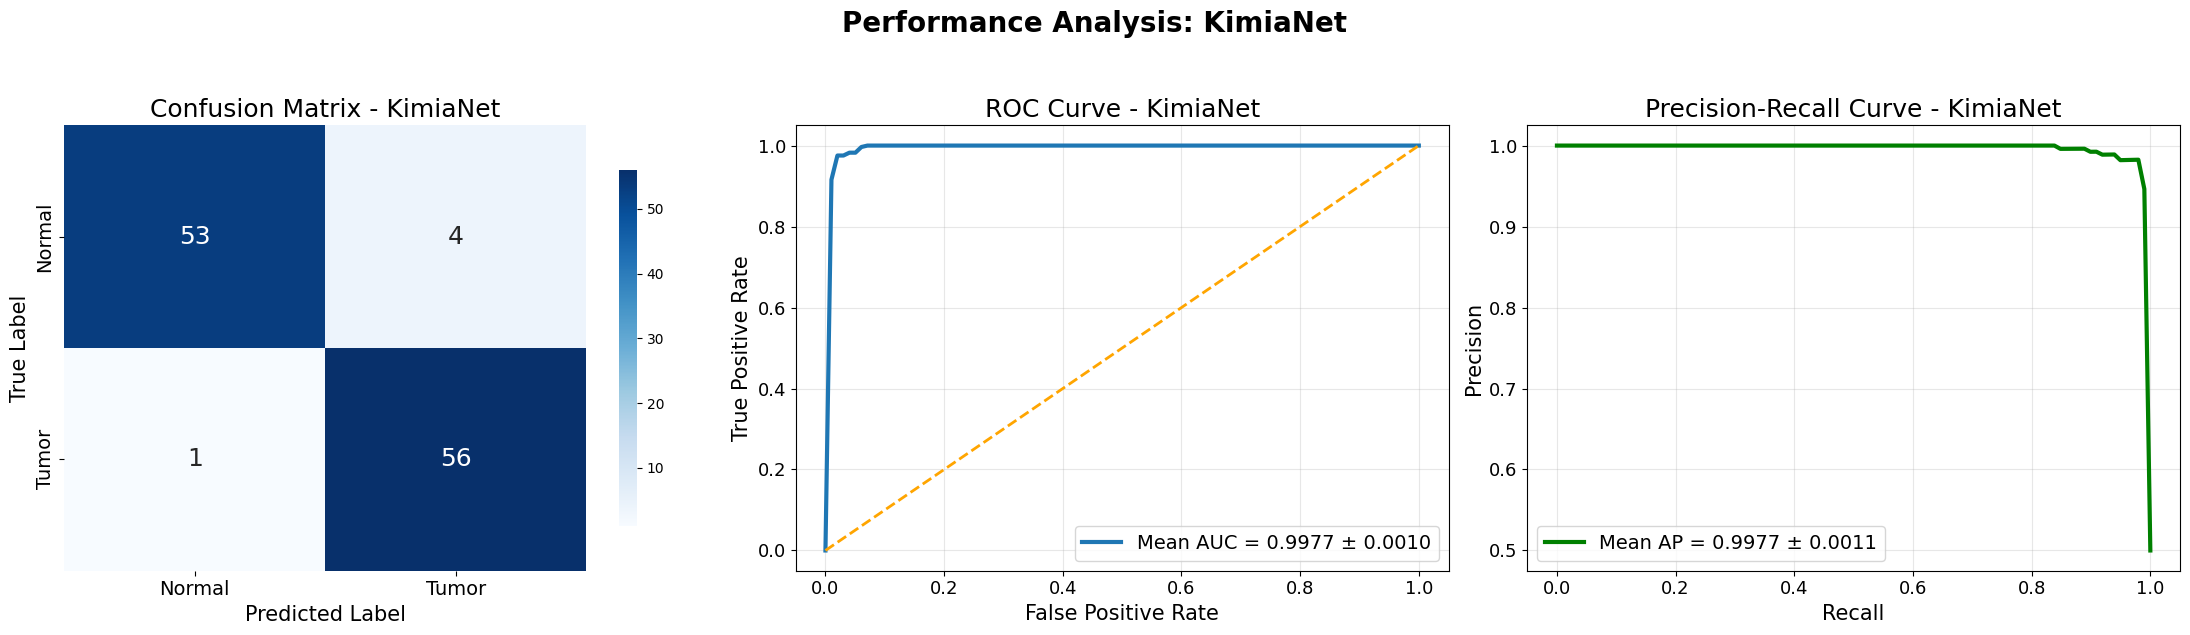


✅ Averaged Testing Finished.


In [ ]:
# --- Configuration for KimiaNet ---
extractor = "KimiaNet"
path = '/content/drive/MyDrive/CPTAC-LSCC_kimianet_features'
dim = 1024
num_runs = 5

# Lists to store final TEST scores for ALL runs (Needed for Plots)
metrics = {'acc': [], 'auc': [], 'f1': [], 'spec': [], 'sens': [], 'prec': []}

all_runs_y_true = []
all_runs_y_probs = []

print(f"\nStarting Averaged Evaluation for {extractor} (Train -> Test x {num_runs})...")

for run in range(num_runs):
    print(f"\n{'='*50}\nRUN {run+1}/{num_runs} for {extractor}")

    # 1. Reset seeds and cache for a clean run
    seed_everything(42 + run)
    torch.cuda.empty_cache()

    # 2. Create a FRESH model for this run
    model = MIL_Max_Pooling_Model(feature_size=dim).to(device)

    # 3. Train the model (This saves the best weights in Drive)
    best_model_path = train_model(model, extractor, path, run)

    # --- TEST PHASE (Immediately after training) ---
    print(f"\nEvaluating Run {run+1} on Independent Test Set...")
    test_loader = DataLoader(MIL_Dataset(os.path.join(path, 'test')), batch_size=1, shuffle=False)

    # Load the best weights saved during THIS specific run
    model.load_state_dict(torch.load(best_model_path))
    model.eval()

    y_true_run, y_probs_run = [], []
    with torch.no_grad():
        for f, l in test_loader:
            logits = model(f.to(device))
            prob = torch.sigmoid(logits).item()
            y_probs_run.append(prob)
            y_true_run.append(int(l.item()))

    y_pred_run = [1 if p >= 0.3 else 0 for p in y_probs_run]

    # Store numerical metrics for averaging
    acc_r = accuracy_score(y_true_run, y_pred_run)
    auc_r = roc_auc_score(y_true_run, y_probs_run)
    tn, fp, fn, tp = confusion_matrix(y_true_run, y_pred_run).ravel()
    metrics['acc'].append(acc_r)
    metrics['auc'].append(auc_r)
    metrics['f1'].append(f1_score(y_true_run, y_pred_run))
    metrics['sens'].append(recall_score(y_true_run, y_pred_run))
    metrics['spec'].append(tn / (tn + fp) if (tn + fp) > 0 else 0)
    metrics['prec'].append(precision_score(y_true_run, y_pred_run))

    # Aggregate labels and probs from THIS run for the final plot
    all_runs_y_true.append(y_true_run)
    all_runs_y_probs.append(y_probs_run)

    print(f"✅ Run {run+1} Complete. Test Acc: {acc_r:.4f} | Test AUC: {auc_r:.4f}")
    del model # Reset memory

# --- FINAL ANALYSIS & PLOTTING ---
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle(f'Performance Analysis: {extractor}', fontsize=20, fontweight='bold', y=1.05)

# ======================================
# AVERAGED CONFUSION MATRIX
# ======================================
cms = []
for y_true, y_probs in zip(all_runs_y_true, all_runs_y_probs):
    y_pred = [1 if p >= 0.3 else 0 for p in y_probs]
    cms.append(confusion_matrix(y_true, y_pred))

cm = np.round(np.mean(cms, axis=0)).astype(int)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Tumor'], yticklabels=['Normal', 'Tumor'],
            annot_kws={"size": 18}, cbar_kws={'shrink': 0.8})

axes[0].set_title(f'Confusion Matrix - {extractor}', fontsize=18)
axes[0].set_xlabel('Predicted Label', fontsize=15)
axes[0].set_ylabel('True Label', fontsize=15)
axes[0].tick_params(labelsize=14)


# ======================================
# AVERAGED ROC CURVE
# ======================================
mean_fpr = np.linspace(0,1,100)
tprs = []
aucs = []

for y_true, y_probs in zip(all_runs_y_true, all_runs_y_probs):
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0
    tprs.append(interp_tpr)
    aucs.append(roc_auc_score(y_true, y_probs))

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0

mean_auc = np.mean(aucs)
std_auc = np.std(aucs)

axes[1].plot(mean_fpr, mean_tpr,
             label=f'Mean AUC = {mean_auc:.4f} ± {std_auc:.4f}', lw=3)

axes[1].plot([0, 1], [0, 1], linestyle='--', color='orange', lw=2)

axes[1].set_title(f'ROC Curve - {extractor}', fontsize=18)
axes[1].set_xlabel('False Positive Rate', fontsize=15)
axes[1].set_ylabel('True Positive Rate', fontsize=15)
axes[1].legend(loc='lower right', fontsize=14)
axes[1].tick_params(labelsize=13)
axes[1].grid(alpha=0.3)


# ======================================
# AVERAGED PR CURVE
# ======================================
mean_recall = np.linspace(0,1,100)
precisions = []
aps = []

for y_true, y_probs in zip(all_runs_y_true, all_runs_y_probs):
    precision, recall, _ = precision_recall_curve(y_true, y_probs)
    interp_prec = np.interp(mean_recall, recall[::-1], precision[::-1])
    precisions.append(interp_prec)
    aps.append(average_precision_score(y_true, y_probs))

print("\n" + "-"*15)
print(f"FINAL AVERAGED TEST RESULTS FOR {extractor} (Mean ± Std)")

print(f"Accuracy:    {np.mean(metrics['acc']):.4f} ± {np.std(metrics['acc']):.4f}")
print(f"AUC Score:   {np.mean(metrics['auc']):.4f} ± {np.std(metrics['auc']):.4f}")
print(f"F1 Score:    {np.mean(metrics['f1']):.4f} ± {np.std(metrics['f1']):.4f}")
print(f"Sensitivity: {np.mean(metrics['sens']):.4f} ± {np.std(metrics['sens']):.4f}")
print(f"Specificity: {np.mean(metrics['spec']):.4f} ± {np.std(metrics['spec']):.4f}")
print(f"Precision:   {np.mean(metrics['prec']):.4f} ± {np.std(metrics['prec']):.4f}")

print("-"*15)
# -----------------------------------------------

mean_precision = np.mean(precisions, axis=0)
mean_ap = np.mean(aps)
std_ap = np.std(aps)

axes[2].plot(mean_recall, mean_precision,
             label=f'Mean AP = {mean_ap:.4f} ± {std_ap:.4f}',
             lw=3, color='green')

axes[2].set_title(f'Precision-Recall Curve - {extractor}', fontsize=18)
axes[2].set_xlabel('Recall', fontsize=15)
axes[2].set_ylabel('Precision', fontsize=15)
axes[2].legend(loc='lower left', fontsize=14)
axes[2].tick_params(labelsize=13)
axes[2].grid(alpha=0.3)


plt.tight_layout()
plt.show()

print("\n✅ Averaged Testing Finished.")


## **CTransPath**

**Completed**


Starting Averaged Evaluation for CTransPath (Train -> Test x 5)...

RUN 1/5 for CTransPath

Training: CTransPath | Run 0
Epoch 01/30 | Val Loss: 0.2542 | Val AUC: 0.9720
--> 
[SAVE] Best model updated with High AUC: 0.9720

Epoch 02/30 | Val Loss: 0.2007 | Val AUC: 0.9760
--> 
[SAVE] Best model updated with High AUC: 0.9760

Epoch 03/30 | Val Loss: 0.1843 | Val AUC: 0.9788
--> 
[SAVE] Best model updated with High AUC: 0.9788

Epoch 04/30 | Val Loss: 0.1873 | Val AUC: 0.9794
--> 
[SAVE] Best model updated with High AUC: 0.9794

No Loss improvement. Patience: 1/15
Epoch 05/30 | Val Loss: 0.1742 | Val AUC: 0.9794
Epoch 06/30 | Val Loss: 0.1781 | Val AUC: 0.9803
--> 
[SAVE] Best model updated with High AUC: 0.9803

No Loss improvement. Patience: 1/15
Epoch 07/30 | Val Loss: 0.1780 | Val AUC: 0.9803
No Loss improvement. Patience: 2/15
Epoch 08/30 | Val Loss: 0.1832 | Val AUC: 0.9815
--> 
[SAVE] Best model updated with High AUC: 0.9815

No Loss improvement. Patience: 3/15
Epoch 09/30 | Val 

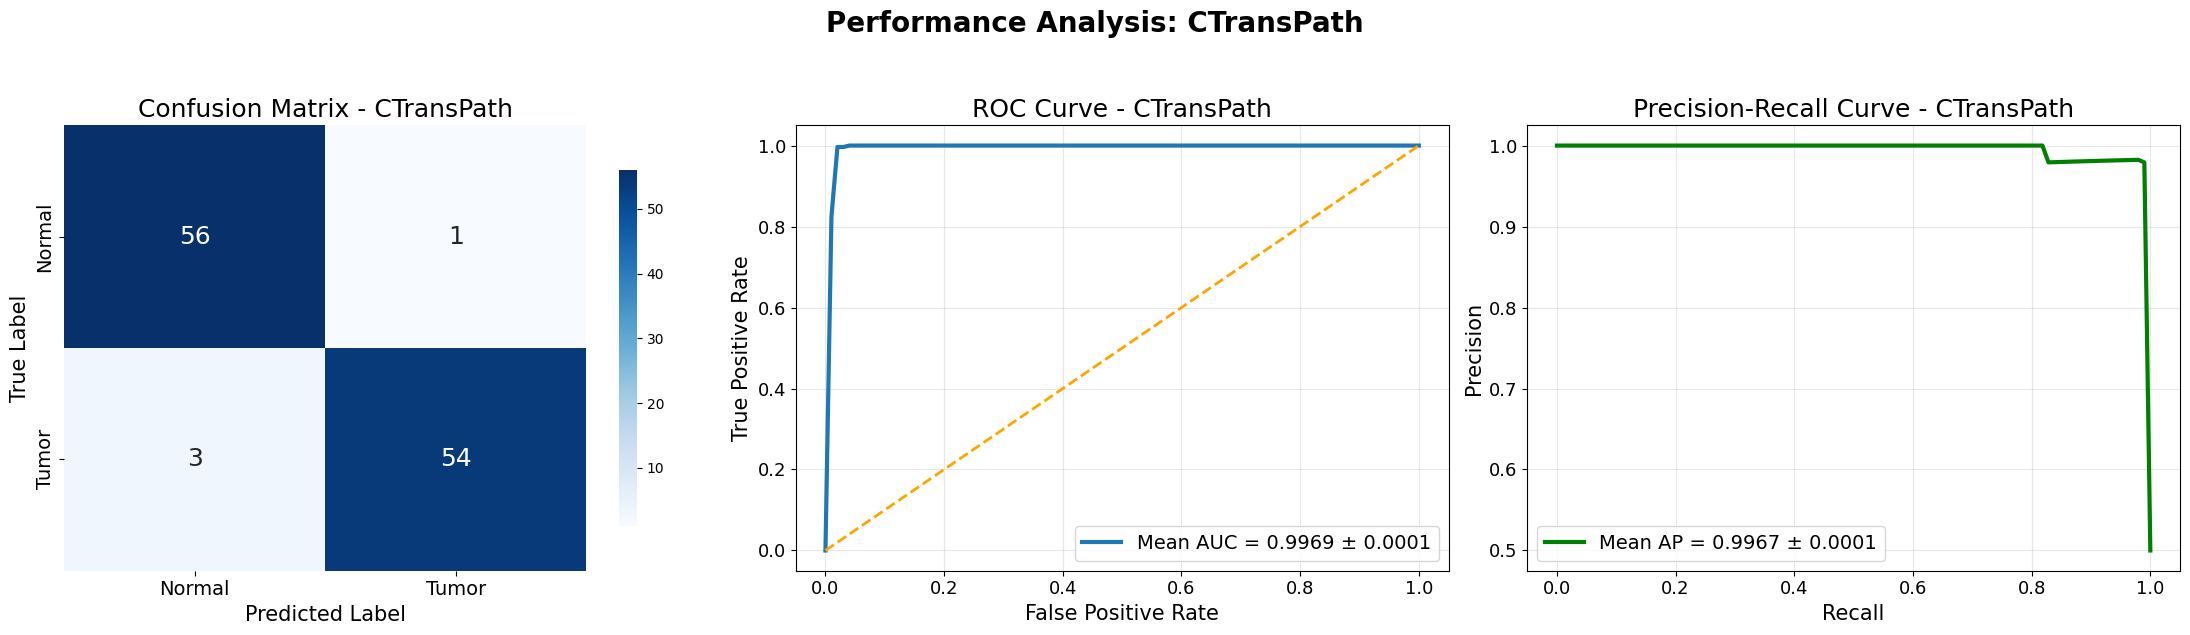


✅ Averaged Testing Finished.


In [ ]:
# --- Configuration for CTransPath ---
extractor = "CTransPath"
path = '/content/drive/MyDrive/CPTAC-LSCC_CTransPath_features'
dim = 768
num_runs = 5

# Lists to store final TEST scores for ALL runs (Needed for Plots)
metrics = {'acc': [], 'auc': [], 'f1': [], 'spec': [], 'sens': [], 'prec': []}

all_runs_y_true = []
all_runs_y_probs = []

print(f"\nStarting Averaged Evaluation for {extractor} (Train -> Test x {num_runs})...")

for run in range(num_runs):
    print(f"\n{'='*50}\nRUN {run+1}/{num_runs} for {extractor}")

    # 1. Reset seeds and cache for a clean run
    seed_everything(42 + run)
    torch.cuda.empty_cache()

    # 2. Create a FRESH model for this run
    model = MIL_Max_Pooling_Model(feature_size=dim).to(device)

    # 3. Train the model (This saves the best weights in Drive)
    best_model_path = train_model(model, extractor, path, run)

    # --- TEST PHASE (Immediately after training) ---
    print(f"\nEvaluating Run {run+1} on Independent Test Set...")
    test_loader = DataLoader(MIL_Dataset(os.path.join(path, 'test')), batch_size=1, shuffle=False)

    # Load the best weights saved during THIS specific run
    model.load_state_dict(torch.load(best_model_path))
    model.eval()

    y_true_run, y_probs_run = [], []
    with torch.no_grad():
        for f, l in test_loader:
            prob = model(f.to(device)).item()
            y_probs_run.append(prob)
            y_true_run.append(int(l.item()))

    y_pred_run = [1 if p >= 0.3 else 0 for p in y_probs_run]

    # Store numerical metrics for averaging
    acc_r = accuracy_score(y_true_run, y_pred_run)
    auc_r = roc_auc_score(y_true_run, y_probs_run)
    tn, fp, fn, tp = confusion_matrix(y_true_run, y_pred_run).ravel()
    metrics['acc'].append(acc_r)
    metrics['auc'].append(auc_r)
    metrics['f1'].append(f1_score(y_true_run, y_pred_run))
    metrics['sens'].append(recall_score(y_true_run, y_pred_run))
    metrics['spec'].append(tn / (tn + fp) if (tn + fp) > 0 else 0)
    metrics['prec'].append(precision_score(y_true_run, y_pred_run))

    # Aggregate labels and probs from THIS run for the final plot
    all_runs_y_true.append(y_true_run)
    all_runs_y_probs.append(y_probs_run)

    print(f"✅ Run {run+1} Complete. Test Acc: {acc_r:.4f} | Test AUC: {auc_r:.4f}")
    del model # Reset memory

# --- FINAL ANALYSIS & PLOTTING ---
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle(f'Performance Analysis: {extractor}', fontsize=20, fontweight='bold', y=1.05)

# ======================================
# AVERAGED CONFUSION MATRIX
# ======================================
cms = []
for y_true, y_probs in zip(all_runs_y_true, all_runs_y_probs):
    y_pred = [1 if p >= 0.3 else 0 for p in y_probs]
    cms.append(confusion_matrix(y_true, y_pred))

cm = np.round(np.mean(cms, axis=0)).astype(int)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Tumor'], yticklabels=['Normal', 'Tumor'],
            annot_kws={"size": 18}, cbar_kws={'shrink': 0.8})

axes[0].set_title(f'Confusion Matrix - {extractor}', fontsize=18)
axes[0].set_xlabel('Predicted Label', fontsize=15)
axes[0].set_ylabel('True Label', fontsize=15)
axes[0].tick_params(labelsize=14)


# ======================================
# AVERAGED ROC CURVE
# ======================================
mean_fpr = np.linspace(0,1,100)
tprs = []
aucs = []

for y_true, y_probs in zip(all_runs_y_true, all_runs_y_probs):
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0
    tprs.append(interp_tpr)
    aucs.append(roc_auc_score(y_true, y_probs))

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0

mean_auc = np.mean(aucs)
std_auc = np.std(aucs)

axes[1].plot(mean_fpr, mean_tpr,
             label=f'Mean AUC = {mean_auc:.4f} ± {std_auc:.4f}', lw=3)

axes[1].plot([0, 1], [0, 1], linestyle='--', color='orange', lw=2)

axes[1].set_title(f'ROC Curve - {extractor}', fontsize=18)
axes[1].set_xlabel('False Positive Rate', fontsize=15)
axes[1].set_ylabel('True Positive Rate', fontsize=15)
axes[1].legend(loc='lower right', fontsize=14)
axes[1].tick_params(labelsize=13)
axes[1].grid(alpha=0.3)


# ======================================
# AVERAGED PR CURVE
# ======================================
mean_recall = np.linspace(0,1,100)
precisions = []
aps = []

for y_true, y_probs in zip(all_runs_y_true, all_runs_y_probs):
    precision, recall, _ = precision_recall_curve(y_true, y_probs)
    interp_prec = np.interp(mean_recall, recall[::-1], precision[::-1])
    precisions.append(interp_prec)
    aps.append(average_precision_score(y_true, y_probs))

print("\n" + "-"*15)
print(f"FINAL AVERAGED TEST RESULTS FOR {extractor} (Mean ± Std)")

print(f"Accuracy:    {np.mean(metrics['acc']):.4f} ± {np.std(metrics['acc']):.4f}")
print(f"AUC Score:   {np.mean(metrics['auc']):.4f} ± {np.std(metrics['auc']):.4f}")
print(f"F1 Score:    {np.mean(metrics['f1']):.4f} ± {np.std(metrics['f1']):.4f}")
print(f"Sensitivity: {np.mean(metrics['sens']):.4f} ± {np.std(metrics['sens']):.4f}")
print(f"Specificity: {np.mean(metrics['spec']):.4f} ± {np.std(metrics['spec']):.4f}")
print(f"Precision:   {np.mean(metrics['prec']):.4f} ± {np.std(metrics['prec']):.4f}")

print("-"*15)
# -----------------------------------------------

mean_precision = np.mean(precisions, axis=0)
mean_ap = np.mean(aps)
std_ap = np.std(aps)

axes[2].plot(mean_recall, mean_precision,
             label=f'Mean AP = {mean_ap:.4f} ± {std_ap:.4f}',
             lw=3, color='green')

axes[2].set_title(f'Precision-Recall Curve - {extractor}', fontsize=18)
axes[2].set_xlabel('Recall', fontsize=15)
axes[2].set_ylabel('Precision', fontsize=15)
axes[2].legend(loc='lower left', fontsize=14)
axes[2].tick_params(labelsize=13)
axes[2].grid(alpha=0.3)


plt.tight_layout()
plt.show()

print("\n✅ Averaged Testing Finished.")


## **MobileNetV2**


Starting Averaged Evaluation for MobileNetV2 (Train -> Test x 5)...

RUN 1/5 for MobileNetV2

Training: MobileNetV2 | Run 0
Epoch 01/30 | Val Loss: 0.2675 | Val AUC: 0.9637
--> 
[SAVE] Best model updated with High AUC: 0.9637

Epoch 02/30 | Val Loss: 0.2259 | Val AUC: 0.9720
--> 
[SAVE] Best model updated with High AUC: 0.9720

Epoch 03/30 | Val Loss: 0.2157 | Val AUC: 0.9745
--> 
[SAVE] Best model updated with High AUC: 0.9745

Epoch 04/30 | Val Loss: 0.2448 | Val AUC: 0.9757
--> 
[SAVE] Best model updated with High AUC: 0.9757

No Loss improvement. Patience: 1/15
Epoch 05/30 | Val Loss: 0.2260 | Val AUC: 0.9754
No Loss improvement. Patience: 2/15
Epoch 06/30 | Val Loss: 0.2213 | Val AUC: 0.9760
--> 
[SAVE] Best model updated with High AUC: 0.9760

No Loss improvement. Patience: 3/15
Epoch 07/30 | Val Loss: 0.2149 | Val AUC: 0.9760
Epoch 08/30 | Val Loss: 0.2203 | Val AUC: 0.9778
--> 
[SAVE] Best model updated with High AUC: 0.9778

No Loss improvement. Patience: 1/15
Epoch 09/30 | V

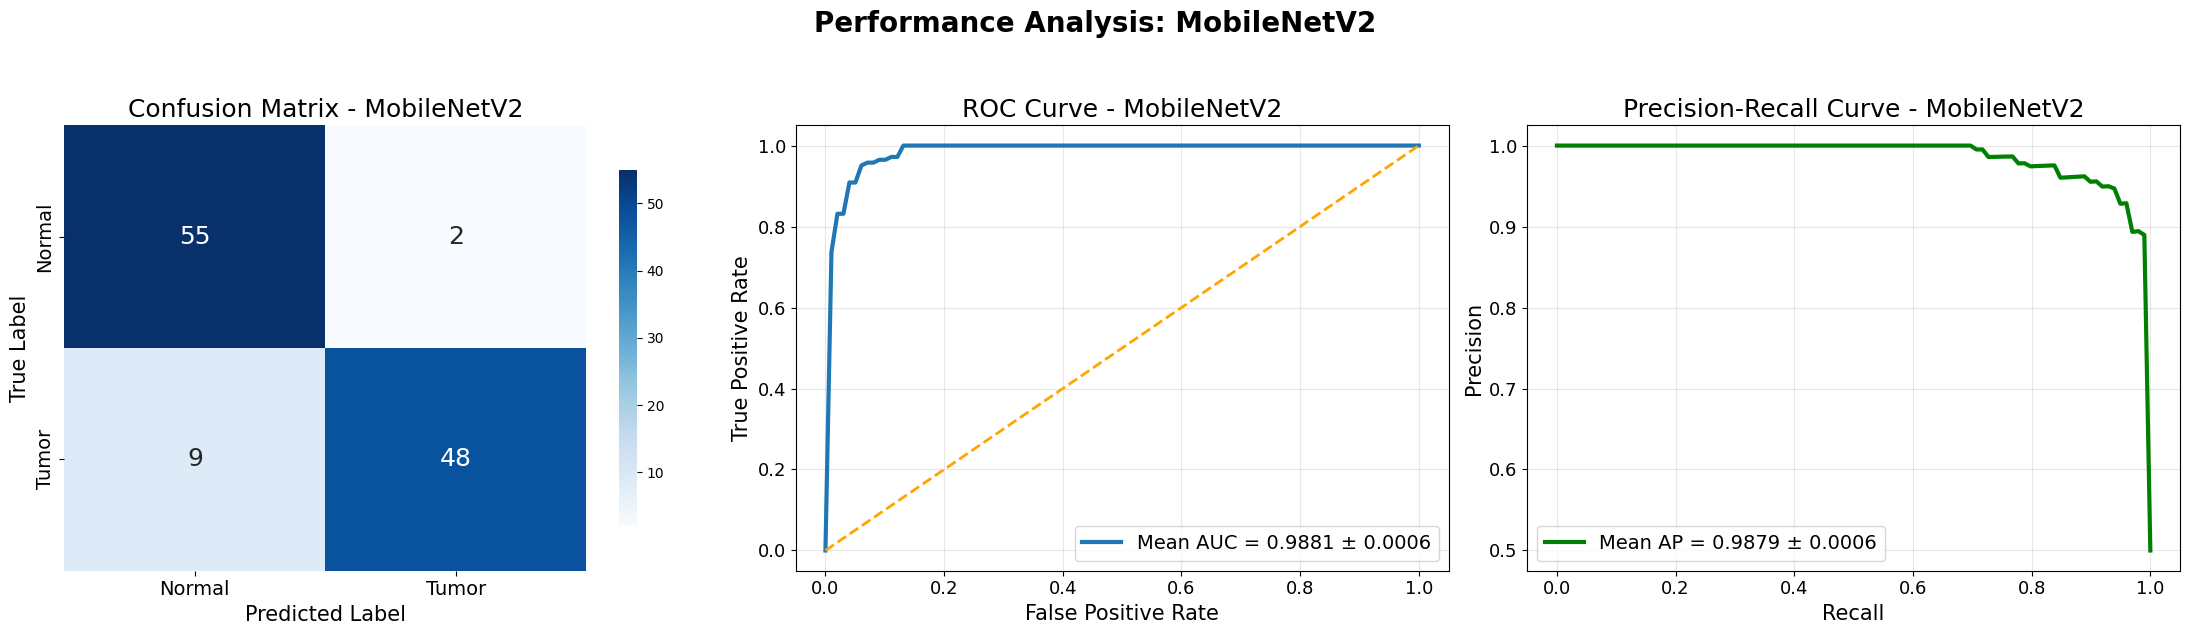


✅ Averaged Testing Finished.


In [ ]:
# --- Configuration for MobileNetV2 ---
extractor = "MobileNetV2"
path = '/content/drive/MyDrive/CPTAC-LSCC_MobileNet_features'
dim = 1280
num_runs = 5

# Lists to store final TEST scores for ALL runs (Needed for Plots)
metrics = {'acc': [], 'auc': [], 'f1': [], 'spec': [], 'sens': [], 'prec': []}

all_runs_y_true = []
all_runs_y_probs = []

print(f"\nStarting Averaged Evaluation for {extractor} (Train -> Test x {num_runs})...")

for run in range(num_runs):
    print(f"\n{'='*50}\nRUN {run+1}/{num_runs} for {extractor}")

    # 1. Reset seeds and cache for a clean run
    seed_everything(42 + run)
    torch.cuda.empty_cache()

    # 2. Create a FRESH model for this run
    model = MIL_Max_Pooling_Model(feature_size=dim).to(device)

    # 3. Train the model (This saves the best weights in Drive)
    best_model_path = train_model(model, extractor, path, run)

    # --- TEST PHASE (Immediately after training) ---
    print(f"\nEvaluating Run {run+1} on Independent Test Set...")
    test_loader = DataLoader(MIL_Dataset(os.path.join(path, 'test')), batch_size=1, shuffle=False)

    # Load the best weights saved during THIS specific run
    model.load_state_dict(torch.load(best_model_path))
    model.eval()

    y_true_run, y_probs_run = [], []
    with torch.no_grad():
        for f, l in test_loader:
            prob = model(f.to(device)).item()
            y_probs_run.append(prob)
            y_true_run.append(int(l.item()))

    y_pred_run = [1 if p >= 0.3 else 0 for p in y_probs_run]

    # Store numerical metrics for averaging
    acc_r = accuracy_score(y_true_run, y_pred_run)
    auc_r = roc_auc_score(y_true_run, y_probs_run)
    tn, fp, fn, tp = confusion_matrix(y_true_run, y_pred_run).ravel()
    metrics['acc'].append(acc_r)
    metrics['auc'].append(auc_r)
    metrics['f1'].append(f1_score(y_true_run, y_pred_run))
    metrics['sens'].append(recall_score(y_true_run, y_pred_run))
    metrics['spec'].append(tn / (tn + fp) if (tn + fp) > 0 else 0)
    metrics['prec'].append(precision_score(y_true_run, y_pred_run))

    # Aggregate labels and probs from THIS run for the final plot
    all_runs_y_true.append(y_true_run)
    all_runs_y_probs.append(y_probs_run)

    print(f"✅ Run {run+1} Complete. Test Acc: {acc_r:.4f} | Test AUC: {auc_r:.4f}")
    del model # Reset memory

# --- FINAL ANALYSIS & PLOTTING ---
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle(f'Performance Analysis: {extractor}', fontsize=20, fontweight='bold', y=1.05)

# ======================================
# AVERAGED CONFUSION MATRIX
# ======================================
cms = []
for y_true, y_probs in zip(all_runs_y_true, all_runs_y_probs):
    y_pred = [1 if p >= 0.3 else 0 for p in y_probs]
    cms.append(confusion_matrix(y_true, y_pred))

cm = np.round(np.mean(cms, axis=0)).astype(int)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Tumor'], yticklabels=['Normal', 'Tumor'],
            annot_kws={"size": 18}, cbar_kws={'shrink': 0.8})

axes[0].set_title(f'Confusion Matrix - {extractor}', fontsize=18)
axes[0].set_xlabel('Predicted Label', fontsize=15)
axes[0].set_ylabel('True Label', fontsize=15)
axes[0].tick_params(labelsize=14)


# ======================================
# AVERAGED ROC CURVE
# ======================================
mean_fpr = np.linspace(0,1,100)
tprs = []
aucs = []

for y_true, y_probs in zip(all_runs_y_true, all_runs_y_probs):
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0
    tprs.append(interp_tpr)
    aucs.append(roc_auc_score(y_true, y_probs))

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0

mean_auc = np.mean(aucs)
std_auc = np.std(aucs)

axes[1].plot(mean_fpr, mean_tpr,
             label=f'Mean AUC = {mean_auc:.4f} ± {std_auc:.4f}', lw=3)

axes[1].plot([0, 1], [0, 1], linestyle='--', color='orange', lw=2)

axes[1].set_title(f'ROC Curve - {extractor}', fontsize=18)
axes[1].set_xlabel('False Positive Rate', fontsize=15)
axes[1].set_ylabel('True Positive Rate', fontsize=15)
axes[1].legend(loc='lower right', fontsize=14)
axes[1].tick_params(labelsize=13)
axes[1].grid(alpha=0.3)


# ======================================
# AVERAGED PR CURVE
# ======================================
mean_recall = np.linspace(0,1,100)
precisions = []
aps = []

for y_true, y_probs in zip(all_runs_y_true, all_runs_y_probs):
    precision, recall, _ = precision_recall_curve(y_true, y_probs)
    interp_prec = np.interp(mean_recall, recall[::-1], precision[::-1])
    precisions.append(interp_prec)
    aps.append(average_precision_score(y_true, y_probs))

print("\n" + "-"*15)
print(f"FINAL AVERAGED TEST RESULTS FOR {extractor} (Mean ± Std)")

print(f"Accuracy:    {np.mean(metrics['acc']):.4f} ± {np.std(metrics['acc']):.4f}")
print(f"AUC Score:   {np.mean(metrics['auc']):.4f} ± {np.std(metrics['auc']):.4f}")
print(f"F1 Score:    {np.mean(metrics['f1']):.4f} ± {np.std(metrics['f1']):.4f}")
print(f"Sensitivity: {np.mean(metrics['sens']):.4f} ± {np.std(metrics['sens']):.4f}")
print(f"Specificity: {np.mean(metrics['spec']):.4f} ± {np.std(metrics['spec']):.4f}")
print(f"Precision:   {np.mean(metrics['prec']):.4f} ± {np.std(metrics['prec']):.4f}")

print("-"*15)
# -----------------------------------------------

mean_precision = np.mean(precisions, axis=0)
mean_ap = np.mean(aps)
std_ap = np.std(aps)

axes[2].plot(mean_recall, mean_precision,
             label=f'Mean AP = {mean_ap:.4f} ± {std_ap:.4f}',
             lw=3, color='green')

axes[2].set_title(f'Precision-Recall Curve - {extractor}', fontsize=18)
axes[2].set_xlabel('Recall', fontsize=15)
axes[2].set_ylabel('Precision', fontsize=15)
axes[2].legend(loc='lower left', fontsize=14)
axes[2].tick_params(labelsize=13)
axes[2].grid(alpha=0.3)


plt.tight_layout()
plt.show()

print("\n✅ Averaged Testing Finished.")


# **External validation**

In [ ]:
def external_validation(extractor_name, external_data_path, model_class, feature_dim, num_runs=5):
    print(f"\n{'='*60}")
    print(f"STARTING EXTERNAL VALIDATION FOR: {extractor_name}")
    print(f"Source Data Path: {external_data_path}")
    print(f"{'='*60}")

    # 1. Prepare DataLoader for the independent external dataset
    external_loader = DataLoader(MIL_Dataset(external_data_path), batch_size=1, shuffle=False)

    # Initialize metrics structure to store scores for each run
    ext_metrics = {'acc': [], 'auc': [], 'f1': [], 'spec': [], 'sens': [], 'prec': []}
    all_runs_y_true = []
    all_runs_y_probs = []

    # 2. Loop through all pre-trained weights (No training happens here)
    for run_idx in range(num_runs):
        # Match the exact naming convention stored in your Google Drive
        weights_path = f"/content/drive/MyDrive/B_New_MIL_Models/best_model_{extractor_name}_run{run_idx}.pth"

        if not os.path.exists(weights_path):
            print(f"Warning: Weights for run {run_idx} not found at {weights_path}. Skipping.")
            continue

        # Create a fresh model instance and load pre-trained weights
        model = model_class(feature_size=feature_dim).to(device)
        model.load_state_dict(torch.load(weights_path, map_location=device))
        model.eval()

        y_true_run, y_probs_run = [], []

        with torch.no_grad():
            for f, l in external_loader:
                prob = model(f.to(device)).item() # Get prediction probability
                y_probs_run.append(prob)
                y_true_run.append(int(l.item()))

        y_pred_run = [1 if p >= 0.3 else 0 for p in y_probs_run]

        # Calculate scores for this run on external data
        acc_r = accuracy_score(y_true_run, y_pred_run)
        auc_r = roc_auc_score(y_true_run, y_probs_run)
        tn, fp, fn, tp = confusion_matrix(y_true_run, y_pred_run).ravel()

        ext_metrics['acc'].append(acc_r)
        ext_metrics['auc'].append(auc_r)
        ext_metrics['f1'].append(f1_score(y_true_run, y_pred_run))
        ext_metrics['sens'].append(recall_score(y_true_run, y_pred_run))
        ext_metrics['spec'].append(tn / (tn + fp) if (tn + fp) > 0 else 0)
        ext_metrics['prec'].append(precision_score(y_true_run, y_pred_run))

        # Collect results for global averaging and visualization
        all_runs_y_true.append(y_true_run)
        all_runs_y_probs.append(y_probs_run)

        print(f"  • Successfully evaluated weights from Run {run_idx+1}/{num_runs} on External Data")
        del model # Clear memory immediately

    # --- 3. PRINT FINAL AVERAGED NUMERICAL RESULTS FIRST ---
    print("\n" + "-"*40)
    print(f"FINAL EXTERNAL VALIDATION RESULTS FOR {extractor_name} (Mean ± Std)")
    print(f"Accuracy:    {np.mean(ext_metrics['acc']):.4f} ± {np.std(ext_metrics['acc']):.4f}")
    print(f"AUC Score:   {np.mean(ext_metrics['auc']):.4f} ± {np.std(ext_metrics['auc']):.4f}")
    print(f"F1 Score:    {np.mean(ext_metrics['f1']):.4f} ± {np.std(ext_metrics['f1']):.4f}")
    print(f"Sensitivity: {np.mean(ext_metrics['sens']):.4f} ± {np.std(ext_metrics['sens']):.4f}")
    print(f"Specificity: {np.mean(ext_metrics['spec']):.4f} ± {np.std(ext_metrics['spec']):.4f}")
    print(f"Precision:   {np.mean(ext_metrics['prec']):.4f} ± {np.std(ext_metrics['prec']):.4f}")
    print("-"*40)

    # --- 4. GENERATE VISUAL PERFORMANCE PANEL (Matching original layout) ---
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    fig.suptitle(f'External Validation Performance Analysis: {extractor_name}', fontsize=20, fontweight='bold', y=1.05)

    # ======================================
    # (A) AVERAGED CONFUSION MATRIX (Using Oranges to indicate External Data)
    # ======================================
    cms = []
    for y_true, y_probs in zip(all_runs_y_true, all_runs_y_probs):
        y_pred = [1 if p >= 0.3 else 0 for p in y_probs]
        cms.append(confusion_matrix(y_true, y_pred))

    cm = np.round(np.mean(cms, axis=0)).astype(int)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
                xticklabels=['Normal', 'Tumor'], yticklabels=['Normal', 'Tumor'],
                annot_kws={"size": 18}, cbar_kws={'shrink': 0.8})

    axes[0].set_title(f'Confusion Matrix (External) - {extractor_name}', fontsize=16)
    axes[0].set_xlabel('Predicted Label', fontsize=15)
    axes[0].set_ylabel('True Label', fontsize=15)
    axes[0].tick_params(labelsize=14)

    # ======================================
    # (B) AVERAGED ROC CURVE
    # ======================================
    mean_fpr = np.linspace(0, 1, 100)
    tprs = []
    aucs = []

    for y_true, y_probs in zip(all_runs_y_true, all_runs_y_probs):
        fpr, tpr, _ = roc_curve(y_true, y_probs)
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0
        tprs.append(interp_tpr)
        aucs.append(roc_auc_score(y_true, y_probs))

    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)

    axes[1].plot(mean_fpr, mean_tpr, color='tab:orange',
                 label=f'Mean AUC = {mean_auc:.4f} ± {std_auc:.4f}', lw=3)
    axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray', lw=2) # Neutral gray reference line

    axes[1].set_title(f'ROC Curve (External) - {extractor_name}', fontsize=16)
    axes[1].set_xlabel('False Positive Rate', fontsize=15)
    axes[1].set_ylabel('True Positive Rate', fontsize=15)
    axes[1].legend(loc='lower right', fontsize=14)
    axes[1].tick_params(labelsize=13)
    axes[1].grid(alpha=0.3)

    # ======================================
    # (C) AVERAGED PR CURVE
    # ======================================
    mean_recall = np.linspace(0, 1, 100)
    precisions = []
    aps = []

    for y_true, y_probs in zip(all_runs_y_true, all_runs_y_probs):
        precision, recall, _ = precision_recall_curve(y_true, y_probs)
        interp_prec = np.interp(mean_recall, recall[::-1], precision[::-1])
        precisions.append(interp_prec)
        aps.append(average_precision_score(y_true, y_probs))

    mean_precision = np.mean(precisions, axis=0)
    mean_ap = np.mean(aps)
    std_ap = np.std(aps)

    axes[2].plot(mean_recall, mean_precision, color='red',
                 label=f'Mean AP = {mean_ap:.4f} ± {std_ap:.4f}', lw=3)

    axes[2].set_title(f'Precision-Recall Curve (External) - {extractor_name}', fontsize=16)
    axes[2].set_xlabel('Recall', fontsize=15)
    axes[2].set_ylabel('Precision', fontsize=15)
    axes[2].legend(loc='lower left', fontsize=14)
    axes[2].tick_params(labelsize=13)
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
    print("\nExternal Validation Process Completed Successfully.")


STARTING EXTERNAL VALIDATION FOR: KimiaNet
Source Data Path: /content/drive/MyDrive/CPTAC-LUAD_kimianet_features/
  • Successfully evaluated weights from Run 1/5 on External Data
  • Successfully evaluated weights from Run 2/5 on External Data
  • Successfully evaluated weights from Run 3/5 on External Data
  • Successfully evaluated weights from Run 4/5 on External Data
  • Successfully evaluated weights from Run 5/5 on External Data

----------------------------------------
FINAL EXTERNAL VALIDATION RESULTS FOR KimiaNet (Mean ± Std)
Accuracy:    0.9017 ± 0.0106
AUC Score:   0.9750 ± 0.0032
F1 Score:    0.8963 ± 0.0144
Sensitivity: 0.8542 ± 0.0453
Specificity: 0.9493 ± 0.0260
Precision:   0.9456 ± 0.0222
----------------------------------------


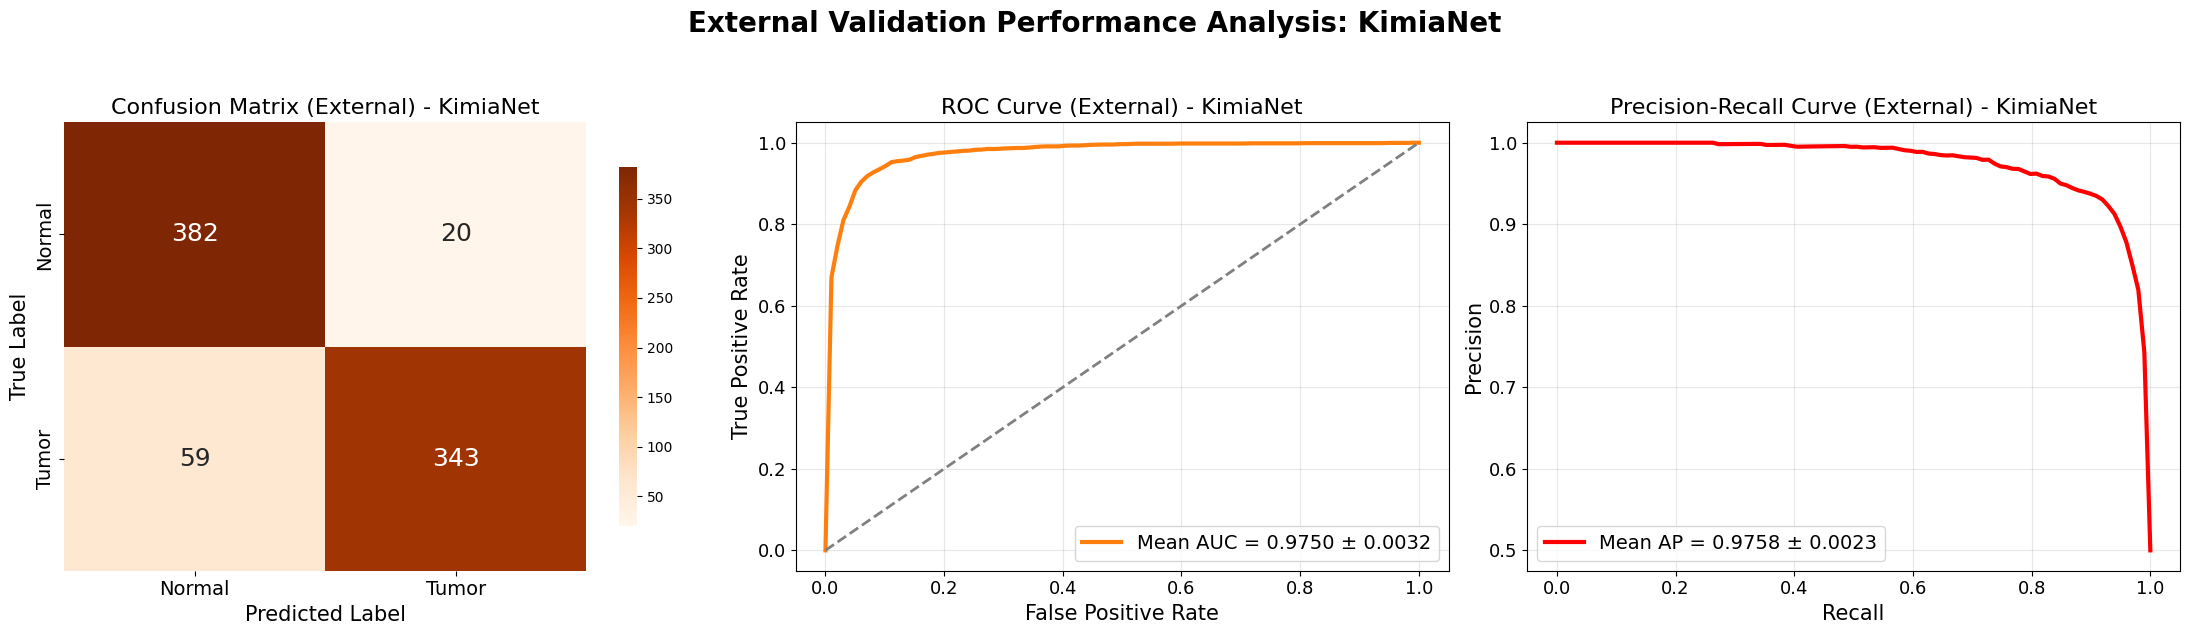


External Validation Process Completed Successfully.


In [ ]:
#kimianet testing
external_dataset_path = "/content/drive/MyDrive/CPTAC-LUAD_kimianet_features/"

external_validation(
    extractor_name="KimiaNet",
    external_data_path=external_dataset_path,
    model_class=MIL_Max_Pooling_Model,
    feature_dim=1024,
    num_runs=5

)

#CTransPath testing



STARTING EXTERNAL VALIDATION FOR: CTransPath
Source Data Path: /content/drive/MyDrive/CPTAC-LUAD_CTransPath_features/
  • Successfully evaluated weights from Run 1/5 on External Data
  • Successfully evaluated weights from Run 2/5 on External Data
  • Successfully evaluated weights from Run 3/5 on External Data
  • Successfully evaluated weights from Run 4/5 on External Data
  • Successfully evaluated weights from Run 5/5 on External Data

----------------------------------------
FINAL EXTERNAL VALIDATION RESULTS FOR CTransPath (Mean ± Std)
Accuracy:    0.8617 ± 0.0197
AUC Score:   0.9926 ± 0.0002
F1 Score:    0.8394 ± 0.0261
Sensitivity: 0.7264 ± 0.0403
Specificity: 0.9970 ± 0.0010
Precision:   0.9960 ± 0.0011
----------------------------------------


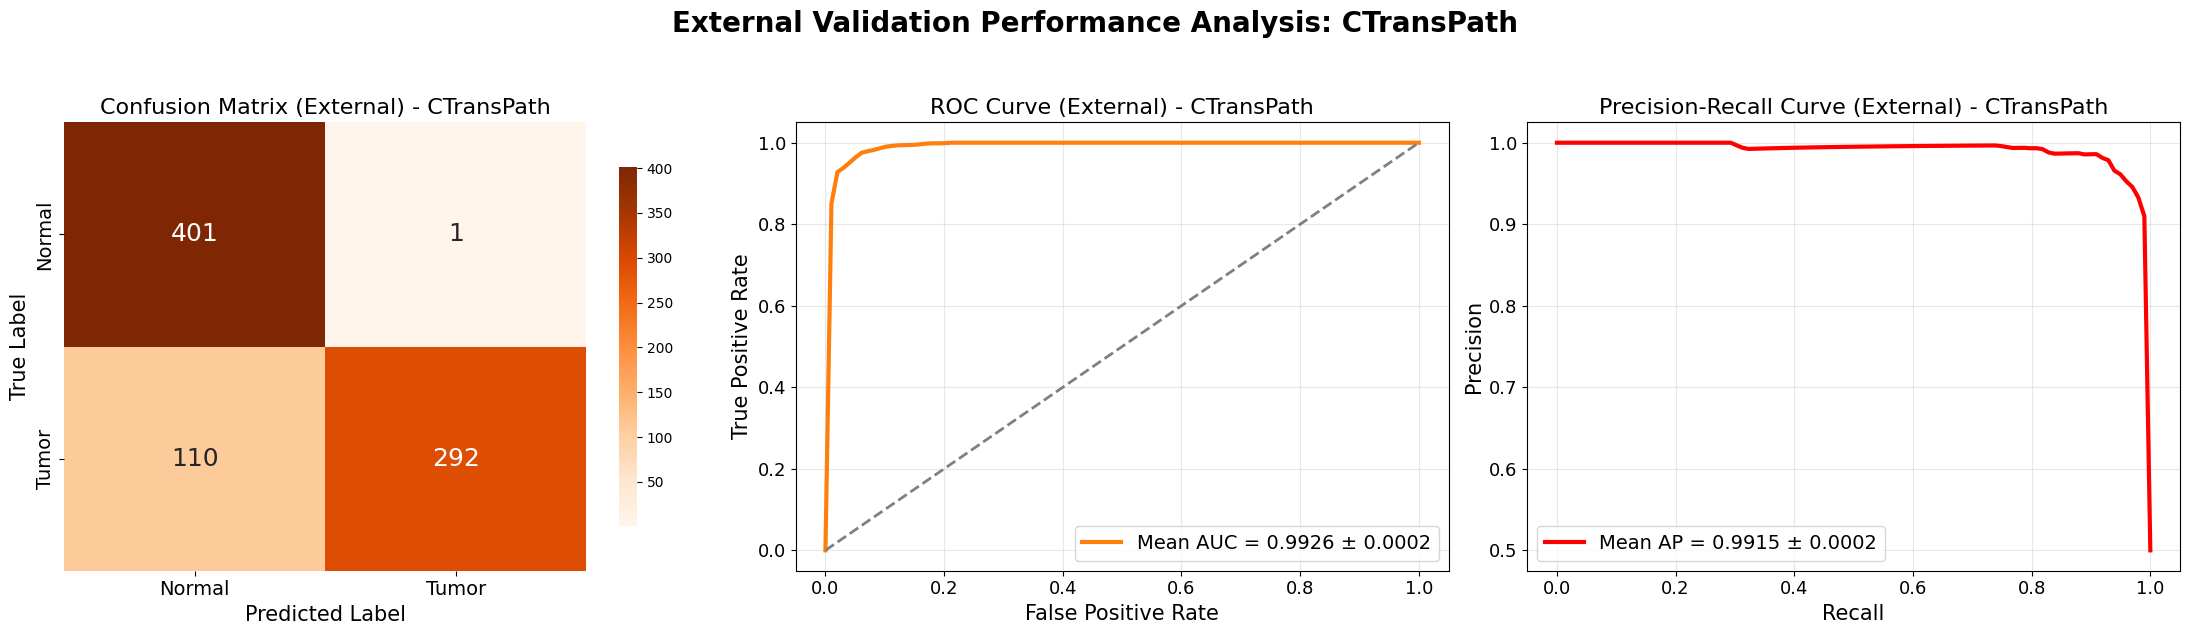


External Validation Process Completed Successfully.


In [ ]:
#CTransPath testing
external_dataset_path = "/content/drive/MyDrive/CPTAC-LUAD_CTransPath_features/"

external_validation(
    extractor_name="CTransPath",
    external_data_path=external_dataset_path,
    model_class=MIL_Max_Pooling_Model,
    feature_dim=768,
    num_runs=5

)

# MobileNet testing


STARTING EXTERNAL VALIDATION FOR: MobileNetV2
Source Data Path: /content/drive/MyDrive/CPTAC-LUAD_MobileNet_features/
  • Successfully evaluated weights from Run 1/5 on External Data
  • Successfully evaluated weights from Run 2/5 on External Data
  • Successfully evaluated weights from Run 3/5 on External Data
  • Successfully evaluated weights from Run 4/5 on External Data
  • Successfully evaluated weights from Run 5/5 on External Data

----------------------------------------
FINAL EXTERNAL VALIDATION RESULTS FOR MobileNetV2 (Mean ± Std)
Accuracy:    0.8236 ± 0.0674
AUC Score:   0.9762 ± 0.0017
F1 Score:    0.7801 ± 0.1091
Sensitivity: 0.6632 ± 0.1434
Specificity: 0.9841 ± 0.0090
Precision:   0.9786 ± 0.0094
----------------------------------------


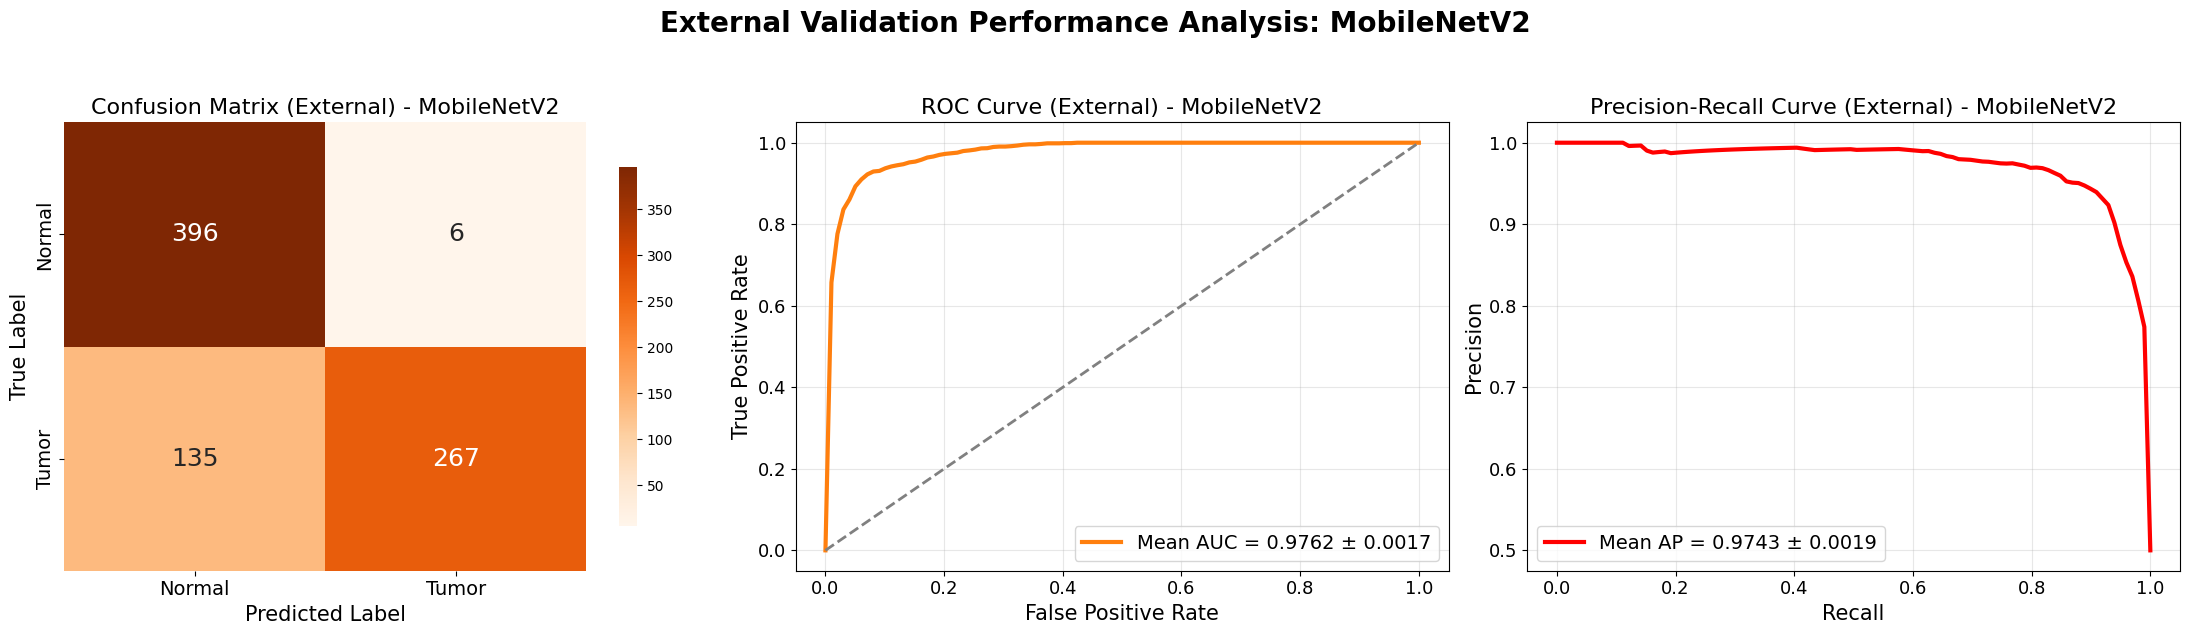


External Validation Process Completed Successfully.


In [ ]:
#MobileNetV2 testing
external_dataset_path = "/content/drive/MyDrive/CPTAC-LUAD_MobileNet_features/"

external_validation(
    extractor_name="MobileNetV2",
    external_data_path=external_dataset_path,
    model_class=MIL_Max_Pooling_Model,
    feature_dim=1280,
    num_runs=5

)